In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from envs import *
from reinforce import *
import torch
from evaluate import *
import gymnasium as gym
import os

# TP1 - Gradiente de Política

### TwoAZeroObsOneStep

In [2]:
env = TwoAZeroObsOneStep()

policy, history = train_reinforce(
    env,
    num_episodes=1000,
    batch_size=10,
    gamma=0.99,
    learning_rate=1e-2,
)

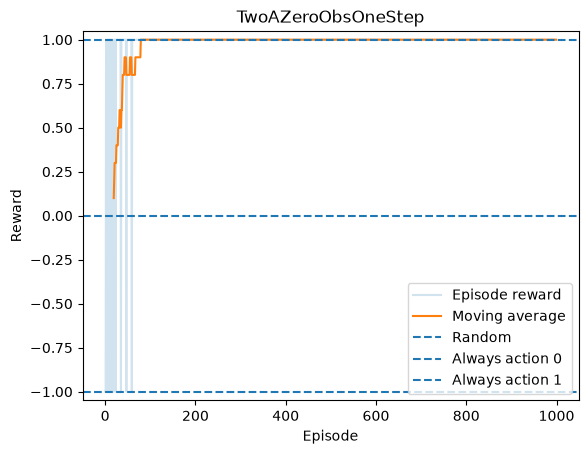

In [3]:
rewards = np.array(history["rewards"])

window = 20

moving_avg = np.convolve(
    rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.plot(
    rewards,
    alpha=0.2,
    label="Episode reward"
)

plt.plot(
    np.arange(window - 1, len(rewards)),
    moving_avg,
    label="Moving average"
)

plt.axhline(0, linestyle="--", label="Random")
plt.axhline(1, linestyle="--", label="Always action 0")
plt.axhline(-1, linestyle="--", label="Always action 1")

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("TwoAZeroObsOneStep")
plt.ylim(-1.05, 1.05)
plt.legend()
plt.show()

In [4]:
state = observation_to_tensor(
    0,
    env.observation_space
)

with torch.no_grad():
    logits = policy(state)
    probs = torch.softmax(logits, dim=-1)

print("Probabilidades:", probs.numpy())

Probabilidades: [9.9992156e-01 7.8432502e-05]


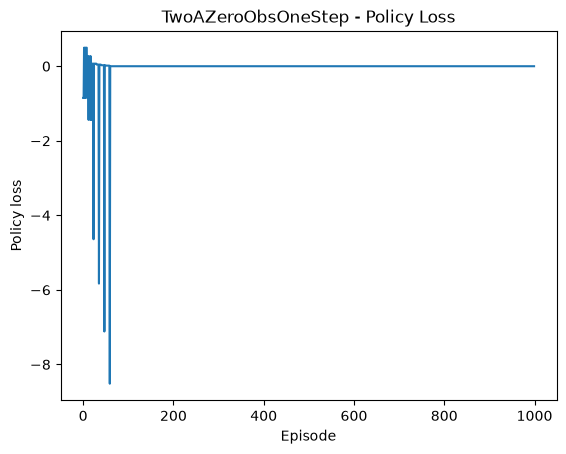

In [5]:
plt.plot(history["episode_losses"])

plt.xlabel("Episode")
plt.ylabel("Policy loss")
plt.title("TwoAZeroObsOneStep - Policy Loss")
plt.show()

In [6]:
os.makedirs("results/weights", exist_ok=True)

torch.save(
    policy.state_dict(),
    "results/weights/TwoAZeroObsOneStep_reinforce.pt"
)

print("Weights saved.")

Weights saved.


### TwoARandomObsOneStep

In [7]:
env = TwoARandomObsOneStep()

policy, history = train_reinforce(
    env,
    num_episodes=1000,
    batch_size=10,
    gamma=0.99,
    learning_rate=1e-2,
)

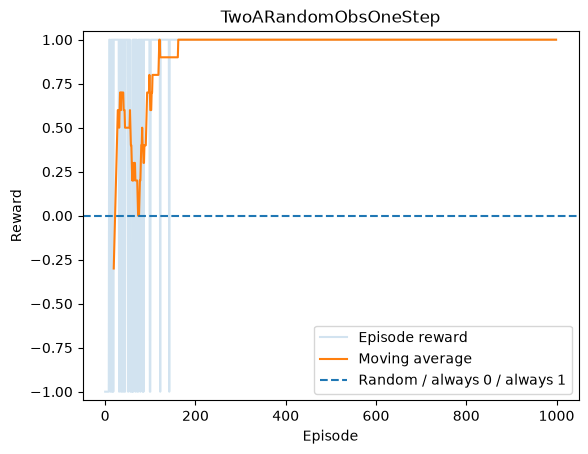

In [8]:
rewards = np.array(history["rewards"])

window = 20

moving_avg = np.convolve(
    rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.plot(
    rewards,
    alpha=0.2,
    label="Episode reward"
)

plt.plot(
    np.arange(window - 1, len(rewards)),
    moving_avg,
    label="Moving average"
)

plt.axhline(0, linestyle="--", label="Random / always 0 / always 1")

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("TwoARandomObsOneStep")
plt.ylim(-1.05, 1.05)
plt.legend()
plt.show()

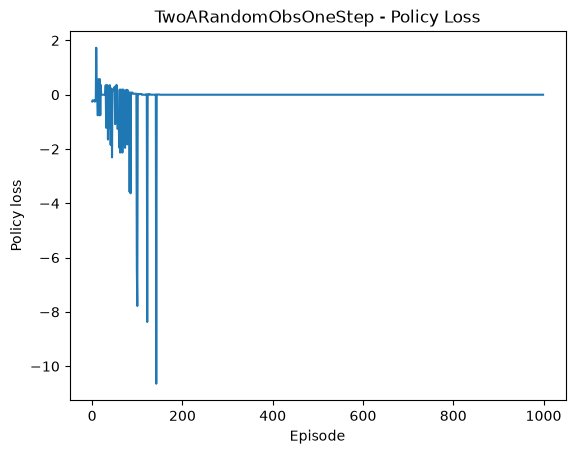

In [9]:
plt.plot(history["episode_losses"])

plt.xlabel("Episode")
plt.ylabel("Policy loss")
plt.title("TwoARandomObsOneStep - Policy Loss")
plt.show()

In [10]:
for obs in [0, 1]:
    state = observation_to_tensor(
        obs,
        env.observation_space
    )

    with torch.no_grad():
        logits = policy(state)
        probs = torch.softmax(logits, dim=-1)

    print(f"Estado {obs}: {probs.numpy()}")

Estado 0: [9.9999499e-01 5.0012763e-06]
Estado 1: [1.2189049e-05 9.9998784e-01]


In [11]:
os.makedirs("results/weights", exist_ok=True)

torch.save(
    policy.state_dict(),
    "results/weights/TwoARandomObsOneStep_reinforce.pt"
)

print("Weights saved.")

Weights saved.


### LineWorldEasyEnv

In [12]:
env = LineWorldEasyEnv()

policy, history = train_reinforce(
    env,
    num_episodes=2000,
    batch_size=10,
    gamma=0.99,
    learning_rate=1e-2,
)

In [13]:
eval_env = LineWorldEasyEnv()

random_return, random_length = evaluate_random_agent(
    eval_env,
    episodes=200
)

always_right_return, always_right_length = evaluate_fixed_action(
    eval_env,
    action=1,
    episodes=200
)

print("Random length:", random_length)
print("Always right length:", always_right_length)

Random length: 29.99
Always right length: 5.0


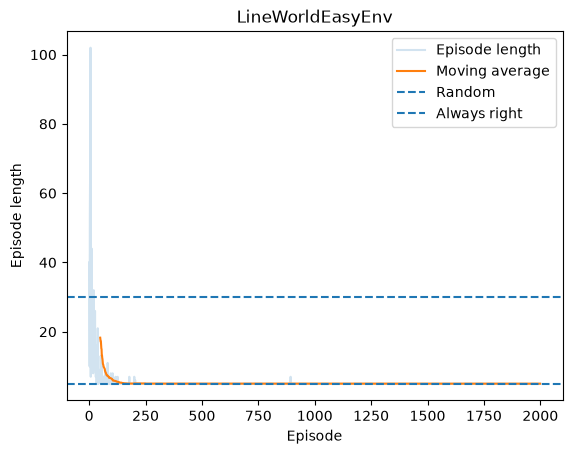

In [14]:
lengths = np.array(history["lengths"])

window = 50

moving_avg_length = np.convolve(
    lengths,
    np.ones(window) / window,
    mode="valid"
)

plt.plot(
    lengths,
    alpha=0.2,
    label="Episode length"
)

plt.plot(
    np.arange(window - 1, len(lengths)),
    moving_avg_length,
    label="Moving average"
)

plt.axhline(
    random_length,
    linestyle="--",
    label="Random"
)

plt.axhline(
    always_right_length,
    linestyle="--",
    label="Always right"
)

plt.xlabel("Episode")
plt.ylabel("Episode length")
plt.title("LineWorldEasyEnv")
plt.legend()
plt.show()

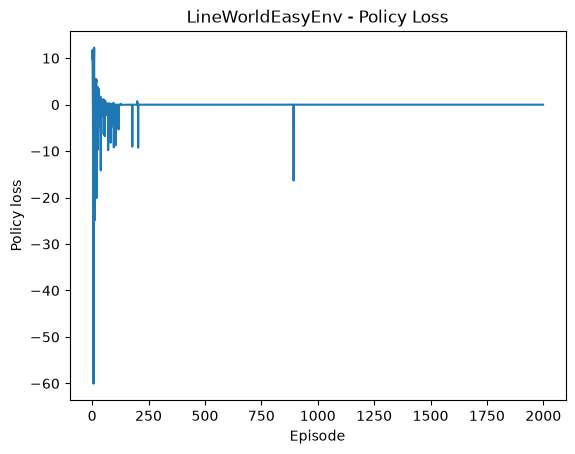

In [15]:
plt.plot(history["episode_losses"])

plt.xlabel("Episode")
plt.ylabel("Policy loss")
plt.title("LineWorldEasyEnv - Policy Loss")
plt.show()

In [16]:
for obs in range(5):
    state = observation_to_tensor(
        obs,
        env.observation_space
    )

    with torch.no_grad():
        logits = policy(state)
        probs = torch.softmax(logits, dim=-1)

    print(f"Estado {obs}: {probs.numpy()}")

Estado 0: [6.950997e-05 9.999305e-01]
Estado 1: [7.7930099e-06 9.9999225e-01]
Estado 2: [1.3694885e-06 9.9999869e-01]
Estado 3: [2.0603195e-06 9.9999797e-01]
Estado 4: [3.859259e-06 9.999962e-01]


In [17]:
os.makedirs("results/weights", exist_ok=True)

torch.save(
    policy.state_dict(),
    "results/weights/LineWorldEasyEnv_reinforce.pt"
)

print("Weights saved.")

Weights saved.


### LineWorldMirrorEnv

In [18]:
env = LineWorldMirrorEnv()

policy, history = train_reinforce(
    env,
    num_episodes=3000,
    batch_size=10,
    gamma=0.99,
    learning_rate=1e-2,
)

In [19]:
eval_env = LineWorldMirrorEnv()

random_return, random_length = evaluate_random_agent(
    eval_env,
    episodes=200
)

print("Random length:", random_length)

Random length: 12.125


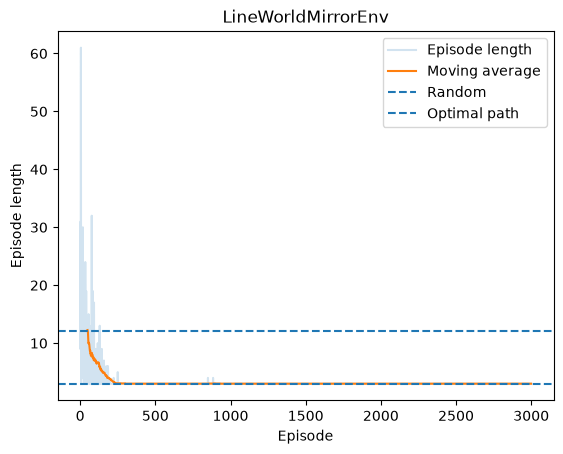

In [20]:
lengths = np.array(history["lengths"])

window = 50

moving_avg_length = np.convolve(
    lengths,
    np.ones(window) / window,
    mode="valid"
)

plt.plot(
    lengths,
    alpha=0.2,
    label="Episode length"
)

plt.plot(
    np.arange(window - 1, len(lengths)),
    moving_avg_length,
    label="Moving average"
)

plt.axhline(
    random_length,
    linestyle="--",
    label="Random"
)

plt.axhline(
    3,
    linestyle="--",
    label="Optimal path"
)

plt.xlabel("Episode")
plt.ylabel("Episode length")
plt.title("LineWorldMirrorEnv")
plt.legend()
plt.show()

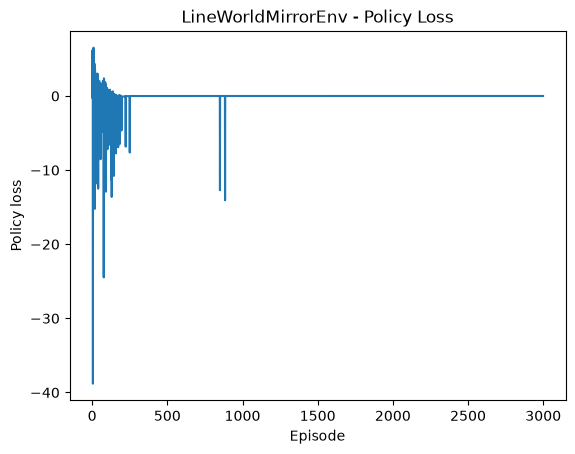

In [21]:
plt.plot(history["episode_losses"])

plt.xlabel("Episode")
plt.ylabel("Policy loss")
plt.title("LineWorldMirrorEnv - Policy Loss")
plt.show()

In [22]:
for obs in range(3):
    state = observation_to_tensor(
        obs,
        env.observation_space
    )

    with torch.no_grad():
        logits = policy(state)
        probs = torch.softmax(logits, dim=-1)

    print(f"Estado {obs}: {probs.numpy()}")

Estado 0: [2.0562622e-05 9.9997950e-01]
Estado 1: [9.9959034e-01 4.0967428e-04]
Estado 2: [1.1056095e-05 9.9998891e-01]


In [23]:
os.makedirs("results/weights", exist_ok=True)

torch.save(
    policy.state_dict(),
    "results/weights/LineWorldMirrorEnv_reinforce.pt"
)

print("Weights saved.")

Weights saved.


### CartPole-v1

In [24]:
env = gym.make("CartPole-v1")

print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Reward threshold:", env.spec.reward_threshold)

Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)
Reward threshold: 475.0


In [25]:
cartpole_policy, cartpole_history = train_reinforce(
    env,
    num_episodes=3000,
    batch_size=10,
    gamma=0.99,
    learning_rate=1e-3,
)

In [26]:
eval_env = gym.make("CartPole-v1")

random_return, _ = evaluate_random_agent(
    eval_env,
    episodes=200
)

always_0_return, _ = evaluate_fixed_action(
    eval_env,
    action=0,
    episodes=200
)

always_1_return, _ = evaluate_fixed_action(
    eval_env,
    action=1,
    episodes=200
)

print("Random:", random_return)
print("Always action 0:", always_0_return)
print("Always action 1:", always_1_return)

Random: 21.255
Always action 0: 9.245
Always action 1: 9.305


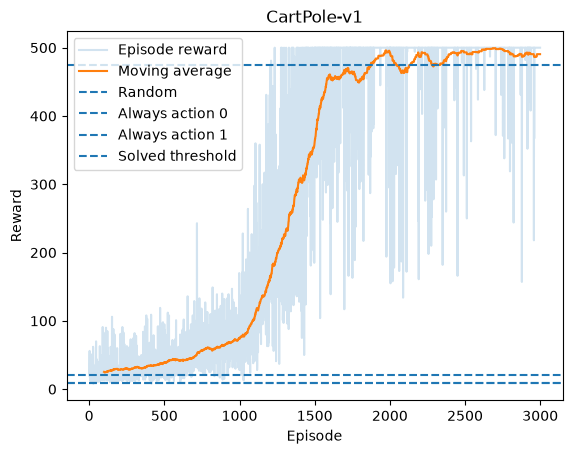

In [ ]:
rewards = np.array(cartpole_history["rewards"])

window = 100

moving_avg = np.convolve(
    rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.plot(
    rewards,
    alpha=0.2,
    label="Episode reward"
)

plt.plot(
    np.arange(window - 1, len(rewards)),
    moving_avg,
    label="Moving average"
)

plt.axhline(
    random_return,
    linestyle="--",
    label="Random"
)

plt.axhline(
    always_0_return,
    linestyle="--",
    label="Always action 0"
)

plt.axhline(
    always_1_return,
    linestyle="--",
    label="Always action 1"
)

if env.spec.reward_threshold is not None:
    plt.axhline(
        env.spec.reward_threshold,
        linestyle="--",
        label="Solved threshold"
    )

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("CartPole-v1")
plt.legend()
plt.show()

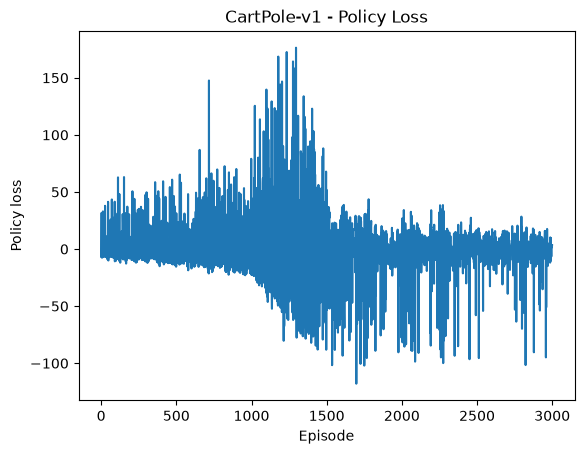

In [28]:
plt.plot(cartpole_history["episode_losses"])

plt.xlabel("Episode")
plt.ylabel("Policy loss")
plt.title("CartPole-v1 - Policy Loss")
plt.show()

In [29]:
mean_return, mean_length, eval_returns, eval_lengths = evaluate_policy(
    eval_env,
    cartpole_policy,
    episodes=100
)

print("Mean deterministic return:", mean_return)
print("Mean deterministic episode length:", mean_length)

Mean deterministic return: 500.0
Mean deterministic episode length: 500.0


In [30]:
os.makedirs("results/weights", exist_ok=True)

torch.save(
    cartpole_policy.state_dict(),
    "results/weights/cartpole_reinforce.pt"
)

print("Weights saved.")

Weights saved.


In [31]:
record_episode(
    "CartPole-v1",
    cartpole_policy,
    "results/videos/cartpole",
    "cartpole_reinforce"
)

/home/joaquin/Documentos/facultad/RL/TPs/TP1_GdeP_DiCola/venv/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /home/joaquin/Documentos/facultad/RL/TPs/TP1_GdeP_DiCola/results/videos/cartpole folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Total reward: 500.0
Episode length: 500
Terminated: False
Truncated: True


### Acrobot-v1

In [32]:
env = gym.make("Acrobot-v1")

print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Reward threshold:", env.spec.reward_threshold)

Observation space: Box([ -1.        -1.        -1.        -1.       -12.566371 -28.274334], [ 1.        1.        1.        1.       12.566371 28.274334], (6,), float32)
Action space: Discrete(3)
Reward threshold: -100.0


In [33]:
eval_env = gym.make("Acrobot-v1")

random_return, _ = evaluate_random_agent(
    eval_env,
    episodes=200
)

always_0_return, _ = evaluate_fixed_action(
    eval_env,
    action=0,
    episodes=200
)

always_1_return, _ = evaluate_fixed_action(
    eval_env,
    action=1,
    episodes=200
)

always_2_return, _ = evaluate_fixed_action(
    eval_env,
    action=2,
    episodes=200
)

print("Random:", random_return)
print("Always action 0:", always_0_return)
print("Always action 1:", always_1_return)
print("Always action 2:", always_2_return)

Random: -497.55
Always action 0: -500.0
Always action 1: -500.0
Always action 2: -500.0


In [34]:
acrobot_policy, acrobot_history = train_reinforce(
    env,
    num_episodes=5000,
    batch_size=10,
    gamma=0.99,
    learning_rate=1e-3,
)

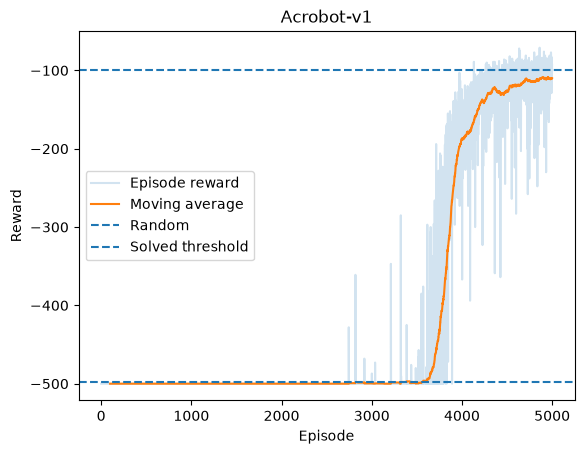

In [35]:
rewards = np.array(acrobot_history["rewards"])

window = 100

moving_avg = np.convolve(
    rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.plot(
    rewards,
    alpha=0.2,
    label="Episode reward"
)

plt.plot(
    np.arange(window - 1, len(rewards)),
    moving_avg,
    label="Moving average"
)

plt.axhline(
    random_return,
    linestyle="--",
    label="Random"
)

if env.spec.reward_threshold is not None:
    plt.axhline(
        env.spec.reward_threshold,
        linestyle="--",
        label="Solved threshold"
    )

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Acrobot-v1")
plt.legend()
plt.show()

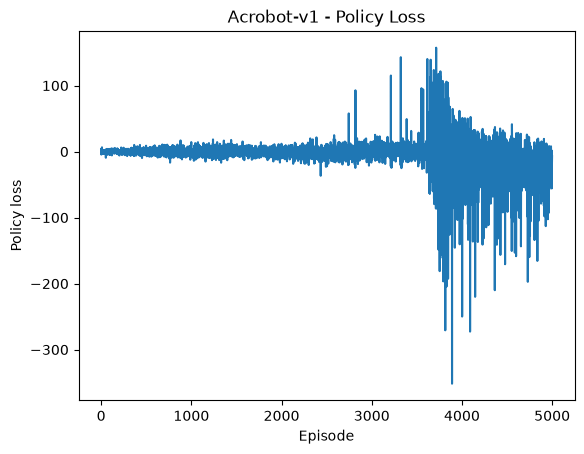

In [36]:
plt.plot(acrobot_history["episode_losses"])

plt.xlabel("Episode")
plt.ylabel("Policy loss")
plt.title("Acrobot-v1 - Policy Loss")
plt.show()

In [37]:
mean_return, mean_length, eval_returns, eval_lengths = evaluate_policy(
    eval_env,
    acrobot_policy,
    episodes=100
)

print("Mean deterministic return:", mean_return)
print("Mean deterministic episode length:", mean_length)

Mean deterministic return: -81.36
Mean deterministic episode length: 82.36


In [38]:
os.makedirs("results/weights", exist_ok=True)

torch.save(
    acrobot_policy.state_dict(),
    "results/weights/acrobot_reinforce.pt"
)

print("Weights saved.")

Weights saved.


In [39]:
record_episode(
    "Acrobot-v1",
    acrobot_policy,
    "results/videos/acrobot",
    "acrobot_reinforce"
)

Total reward: -86.0
Episode length: 87
Terminated: True
Truncated: False


/home/joaquin/Documentos/facultad/RL/TPs/TP1_GdeP_DiCola/venv/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /home/joaquin/Documentos/facultad/RL/TPs/TP1_GdeP_DiCola/results/videos/acrobot folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


## REINFORCE con Baseline

In [78]:
env = gym.make("CartPole-v1")

cartpole_baseline_policy, cartpole_value, cartpole_baseline_history = (
    train_reinforce_with_baseline(
        env,
        num_episodes=3000,
        batch_size=10,
        gamma=0.99,
        policy_learning_rate=1e-3,
        value_learning_rate=1e-3,
    )
)

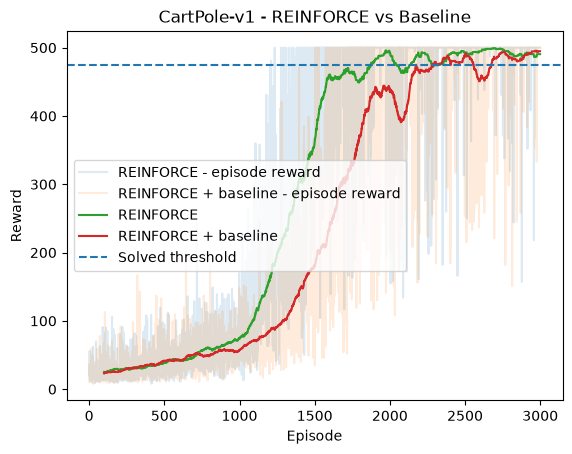

In [79]:
window = 100

cartpole_rewards = np.array(cartpole_history["rewards"])
baseline_rewards = np.array(cartpole_baseline_history["rewards"])

cartpole_moving_avg = np.convolve(
    cartpole_rewards,
    np.ones(window) / window,
    mode="valid"
)

baseline_moving_avg = np.convolve(
    baseline_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.plot(
    cartpole_rewards,
    alpha=0.15,
    label="REINFORCE - episode reward"
)

plt.plot(
    baseline_rewards,
    alpha=0.15,
    label="REINFORCE + baseline - episode reward"
)

plt.plot(
    np.arange(window - 1, len(cartpole_rewards)),
    cartpole_moving_avg,
    label="REINFORCE"
)

plt.plot(
    np.arange(window - 1, len(baseline_rewards)),
    baseline_moving_avg,
    label="REINFORCE + baseline"
)

plt.axhline(
    475,
    linestyle="--",
    label="Solved threshold"
)

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("CartPole-v1 - REINFORCE vs Baseline")
plt.legend()
plt.show()

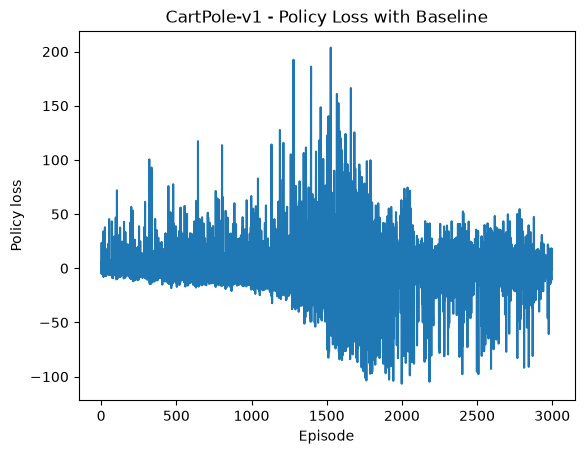

In [80]:
plt.plot(
    cartpole_baseline_history["episode_losses"]
)

plt.xlabel("Episode")
plt.ylabel("Policy loss")
plt.title("CartPole-v1 - Policy Loss with Baseline")
plt.show()

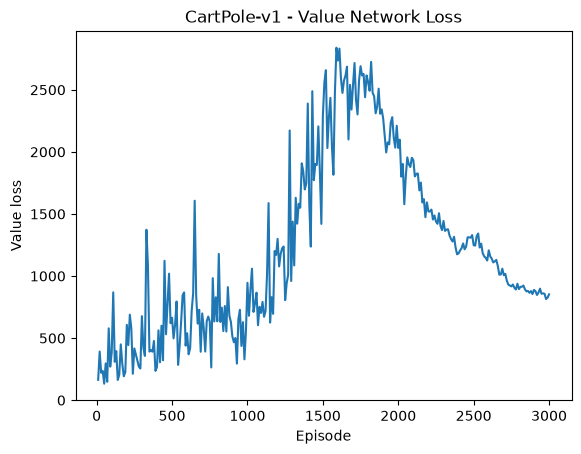

In [81]:
plt.plot(
    np.arange(
        10,
        10 * len(cartpole_baseline_history["value_losses"]) + 1,
        10
    ),
    cartpole_baseline_history["value_losses"]
)

plt.xlabel("Episode")
plt.ylabel("Value loss")
plt.title("CartPole-v1 - Value Network Loss")
plt.show()

In [82]:
eval_env = gym.make("CartPole-v1")

mean_return, mean_length, _, _ = evaluate_policy(
    eval_env,
    cartpole_baseline_policy,
    episodes=100
)

print("Baseline mean deterministic return:", mean_return)
print("Baseline mean deterministic episode length:", mean_length)

Baseline mean deterministic return: 500.0
Baseline mean deterministic episode length: 500.0


In [83]:
threshold = 475
window = 100

reinforce_ma = np.convolve(
    np.array(cartpole_history["rewards"]),
    np.ones(window) / window,
    mode="valid"
)

baseline_ma = np.convolve(
    np.array(cartpole_baseline_history["rewards"]),
    np.ones(window) / window,
    mode="valid"
)

reinforce_crossings = np.where(reinforce_ma >= threshold)[0]
baseline_crossings = np.where(baseline_ma >= threshold)[0]

reinforce_solved = (
    reinforce_crossings[0] + window - 1
    if len(reinforce_crossings) > 0
    else None
)

baseline_solved = (
    baseline_crossings[0] + window - 1
    if len(baseline_crossings) > 0
    else None
)

print("REINFORCE reaches threshold at episode:", reinforce_solved)
print("Baseline reaches threshold at episode:", baseline_solved)

REINFORCE reaches threshold at episode: 1873
Baseline reaches threshold at episode: 2175


In [84]:
torch.save(
    cartpole_baseline_policy.state_dict(),
    "results/weights/cartpole_reinforce_baseline.pt"
)

torch.save(
    cartpole_value.state_dict(),
    "results/weights/cartpole_value.pt"
)

### Acrobot-v1

In [85]:
env = gym.make("Acrobot-v1")

acrobot_baseline_policy, acrobot_value, acrobot_baseline_history = (
    train_reinforce_with_baseline(
        env,
        num_episodes=5000,
        batch_size=10,
        gamma=0.99,
        policy_learning_rate=1e-3,
        value_learning_rate=1e-3,
        value_epochs=5,
    )
)

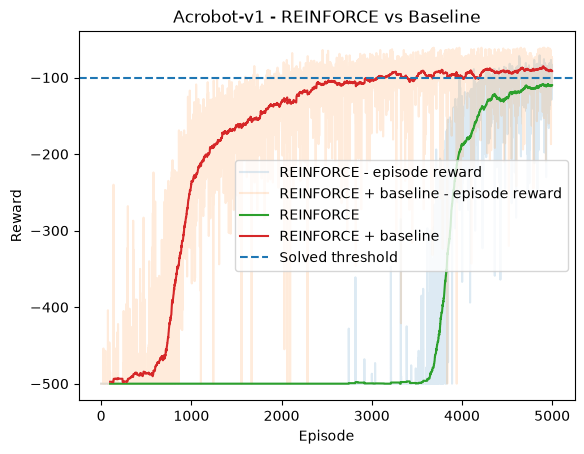

In [86]:
window = 100

acrobot_rewards = np.array(
    acrobot_history["rewards"]
)

baseline_rewards = np.array(
    acrobot_baseline_history["rewards"]
)

acrobot_moving_avg = np.convolve(
    acrobot_rewards,
    np.ones(window) / window,
    mode="valid"
)

baseline_moving_avg = np.convolve(
    baseline_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.plot(
    acrobot_rewards,
    alpha=0.15,
    label="REINFORCE - episode reward"
)

plt.plot(
    baseline_rewards,
    alpha=0.15,
    label="REINFORCE + baseline - episode reward"
)

plt.plot(
    np.arange(window - 1, len(acrobot_rewards)),
    acrobot_moving_avg,
    label="REINFORCE"
)

plt.plot(
    np.arange(window - 1, len(baseline_rewards)),
    baseline_moving_avg,
    label="REINFORCE + baseline"
)

plt.axhline(
    -100,
    linestyle="--",
    label="Solved threshold"
)

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Acrobot-v1 - REINFORCE vs Baseline")
plt.legend()
plt.show()

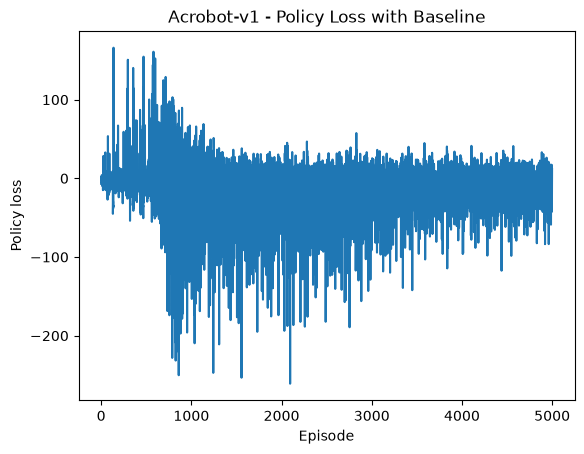

In [87]:
plt.plot(
    acrobot_baseline_history["episode_losses"]
)

plt.xlabel("Episode")
plt.ylabel("Policy loss")
plt.title("Acrobot-v1 - Policy Loss with Baseline")
plt.show()

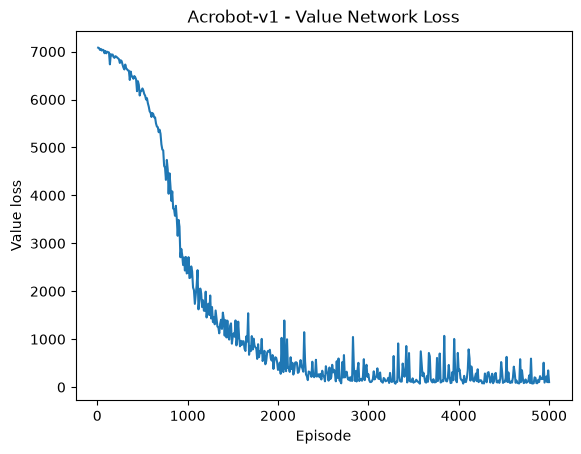

In [88]:
value_losses = acrobot_baseline_history["value_losses"]

value_loss_steps = np.arange(
    1,
    len(value_losses) + 1
) * 10

plt.plot(
    value_loss_steps,
    value_losses
)

plt.xlabel("Episode")
plt.ylabel("Value loss")
plt.title("Acrobot-v1 - Value Network Loss")
plt.show()

In [89]:
eval_env = gym.make("Acrobot-v1")

mean_return, mean_length, _, _ = evaluate_policy(
    eval_env,
    acrobot_baseline_policy,
    episodes=100
)

print(
    "Baseline mean deterministic return:",
    mean_return
)

print(
    "Baseline mean deterministic episode length:",
    mean_length
)

Baseline mean deterministic return: -88.23
Baseline mean deterministic episode length: 89.23


In [90]:
threshold = -100
window = 100

reinforce_ma = np.convolve(
    np.array(acrobot_history["rewards"]),
    np.ones(window) / window,
    mode="valid"
)

baseline_ma = np.convolve(
    np.array(acrobot_baseline_history["rewards"]),
    np.ones(window) / window,
    mode="valid"
)

reinforce_crossings = np.where(
    reinforce_ma >= threshold
)[0]

baseline_crossings = np.where(
    baseline_ma >= threshold
)[0]

reinforce_solved = (
    reinforce_crossings[0] + window - 1
    if len(reinforce_crossings) > 0
    else None
)

baseline_solved = (
    baseline_crossings[0] + window - 1
    if len(baseline_crossings) > 0
    else None
)

print(
    "REINFORCE reaches threshold at episode:",
    reinforce_solved
)

print(
    "Baseline reaches threshold at episode:",
    baseline_solved
)

REINFORCE reaches threshold at episode: None
Baseline reaches threshold at episode: 3071


In [91]:
torch.save(
    acrobot_baseline_policy.state_dict(),
    "results/weights/acrobot_reinforce_baseline.pt"
)

torch.save(
    acrobot_value.state_dict(),
    "results/weights/acrobot_value.pt"
)